# Setup

In [29]:
!pip install langgraph

In [ ]:
!pip install langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.0 MB/s eta 0:00:00


In [ ]:
!pip install langgraph-prebuilt

In [ ]:
from IPython.display import HTML, Markdown, display

In [35]:
from google.colab import userdata
api_key = userdata.get('GOOGLE_API_KEY')

In [ ]:
import os
from google import genai
from google.genai import types
from google.adk.agents import LlmAgent
from google.adk.models.google_llm import Gemini
from google.adk.runners import InMemoryRunner, Runner
from google.adk.sessions import InMemorySessionService
from google.adk.tools import google_search, AgentTool, ToolContext
from google.adk.code_executors import BuiltInCodeExecutor

/usr/local/lib/python3.12/dist-packages/google/adk/features/_feature_decorator.py:72: UserWarning: [EXPERIMENTAL] feature FeatureName.PLUGGABLE_AUTH is enabled.
  check_feature_enabled()


In [ ]:
retry_config = types.HttpRetryOptions(
    attempts=5,  # Maximum retry attempts
    exp_base=7,  # Delay multiplier
    initial_delay=1,
    http_status_codes=[429, 500, 503, 504],  # Retry on these HTTP errors
)

In [ ]:
# Set API key as environment variable
os.environ['GOOGLE_API_KEY'] = userdata.get('GOOGLE_API_KEY')

client = genai.Client(api_key=api_key)

for model in client.models.list():
  print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-preview-10-2025

In [ ]:
# Define helper functions that will be reused throughout the notebook
async def run_session(
    runner_instance: Runner,
    user_queries: list[str] | str = None,
    session_name: str = "default",
):
    print(f"\n ### Session: {session_name}")

    # Get app name from the Runner
    app_name = runner_instance.app_name

    # Attempt to create a new session or retrieve an existing one
    try:
        session = await session_service.create_session(
            app_name=app_name, user_id=USER_ID, session_id=session_name
        )
    except:
        session = await session_service.get_session(
            app_name=app_name, user_id=USER_ID, session_id=session_name
        )

    # Process queries if provided
    if user_queries:
        # Convert single query to list for uniform processing
        if type(user_queries) == str:
            user_queries = [user_queries]

        # Process each query in the list sequentially
        for query in user_queries:
            print(f"\nUser > {query}")

            # Convert the query string to the ADK Content format
            query = types.Content(role="user", parts=[types.Part(text=query)])

            # Stream the agent's response asynchronously
            async for event in runner_instance.run_async(
                user_id=USER_ID, session_id=session.id, new_message=query
            ):
                # Check if the event contains valid content
                if event.content and event.content.parts:
                    # Filter out empty or "None" responses before printing
                    if (
                        event.content.parts[0].text != "None"
                        and event.content.parts[0].text
                    ):
                        print(f"{MODEL_NAME} > ", event.content.parts[0].text)
    else:
        print("No queries!")


print("Helper functions defined.")

Helper functions defined.


# 1. LangGraph Concepts

LangGraph applications are built around a **graph** structure. As the developer, you define an application graph that models the state transitions for your application. Your app will define a **state** schema, and an instance of that schema is propagated through the graph.

<br>

Each **node** in the graph represents an action or step that can be taken. Nodes will make changes to the state in some way through code that you define. These changes can be the result of invoking an LLM, by calling an API, or executing any logic that the node defines.

<br>

Each **edge** in the graph represents a transition between states, defining the flow of the program. Edge transitions can be fixed, for example if you define a text-only chatbot where output is always displayed to a user, you may always transition from `chatbot -> user`. The transitions can also be conditional, allowing you to add branching (like an `if-else` statement) or looping (like `for` or `while` loops).

## 1.1) Defining Core Instructions (Barrista Bot)

State is a fundamental concept for a LangGraph app. A state object is passed between every node and transition in the app. Here you define a state object, OrderState, that holds the conversation history, a structured order, and a flag indicating if the customer has finished placing their order. For simplicity, the "structure" in this order is just a list of strings, but this can be expanded to any Python data structure.

In Python, the LangGraph state object is a Python dictionary. You can provide a schema for this dictionary by defining it as a TypedDict.

Here you also define the system instruction that the Gemini model will use. You can capture tone and style here, as well as the playbook under which the chatbot should operate.

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages


class OrderState(TypedDict):
    """State representing the customer's order conversation."""

    # The chat conversation. This preserves the conversation history
    # between nodes. The `add_messages` annotation indicates to LangGraph
    # that state is updated by appending returned messages, not replacing
    # them.
    messages: Annotated[list, add_messages]

    # The customer's in-progress order.
    order: list[str]

    # Flag indicating that the order is placed and completed.
    finished: bool


# The system instruction defines how the chatbot is expected to behave and includes
# rules for when to call different functions, as well as rules for the conversation, such
# as tone and what is permitted for discussion.
BARISTABOT_SYSINT = (
    "system",  # 'system' indicates the message is a system instruction.
    "You are a BaristaBot, an interactive cafe ordering system. A human will talk to you about the "
    "available products you have and you will answer any questions about menu items (and only about "
    "menu items - no off-topic discussion, but you can chat about the products and their history). "
    "The customer will place an order for 1 or more items from the menu, which you will structure "
    "and send to the ordering system after confirming the order with the human. "
    "\n\n"
    "Add items to the customer's order with add_to_order, and reset the order with clear_order. "
    "To see the contents of the order so far, call get_order (this is shown to you, not the user) "
    "Always confirm_order with the user (double-check) before calling place_order. Calling confirm_order will "
    "display the order items to the user and returns their response to seeing the list. Their response may contain modifications. "
    "Always verify and respond with drink and modifier names from the MENU before adding them to the order. "
    "If you are unsure a drink or modifier matches those on the MENU, ask a question to clarify or redirect. "
    "You only have the modifiers listed on the menu. "
    "Once the customer has finished ordering items, Call confirm_order to ensure it is correct then make "
    "any necessary updates and then call place_order. Once place_order has returned, thank the user and "
    "say goodbye!"
    "\n\n"
    "If any of the tools are unavailable, you can break the fourth wall and tell the user that "
    "they have not implemented them yet and should keep reading to do so.",
)

# This is the message with which the system opens the conversation.
WELCOME_MSG = "Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?"

The following program defines a chatbot node that will execute a single turn in a chat conversation using the instructions supplied.

Each node in the graph operates on the state object. The state (a Python dictionary) is passed as a parameter into the node (a function) and the new state is returned. This can be restated as pseudo-code, where `state = node(state)`.

Note: For the `chatbot` node, the state is updated by *adding* the new conversation message. The `add_messages` annotation on `OrderState.messages` indicates that messages are appended when returned from a node. Typically state is updated by replacement, but this annotation causes `messages` to behave differently.

In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

def chatbot(state: OrderState) -> OrderState:
    """The chatbot itself. A simple wrapper around the model's own chat interface."""
    message_history = [BARISTABOT_SYSINT] + state["messages"]
    return {"messages": [llm.invoke(message_history)]}

# Set up the initial graph based on our state definition.
graph_builder = StateGraph(OrderState)

# Add the chatbot function to the app graph as a node called "chatbot".
graph_builder.add_node("chatbot", chatbot)

# Define the chatbot node as the app entrypoint.
graph_builder.add_edge(START, "chatbot")

chat_graph = graph_builder.compile()

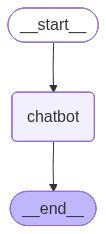

In [ ]:
from IPython.display import Image, display

Image(chat_graph.get_graph().draw_mermaid_png())

Now that the graph is defined, you can run it. It only has one node, and one transition into that node, so it will transition from `__start__` to `chatbot`, execute the `chatbot` node, and terminate.

To run the graph, you call `invoke` and pass an initial state object. In this case it begins with the user's initial message.

In [ ]:
from pprint import pprint

user_msg = "Hello, what can you do?"
state = chat_graph.invoke({"messages": [user_msg]})

# Note that the final state now has 2 messages. Our HumanMessage, and an additional AIMessage.
for msg in state["messages"]:
    print(f"{type(msg).__name__}: {msg.content}")

HumanMessage: Hello, what can you do?
AIMessage: Hello! I'm BaristaBot, your friendly cafe ordering system. I can help you explore our menu and place an order for your favorite drinks and snacks. What can I get started for you today?


In [ ]:
# The state object contains lots of information.
pprint(state)

{'messages': [HumanMessage(content='Hello, what can you do?', additional_kwargs={}, response_metadata={}, id='c9b31593-f4b8-4d2d-a2cc-8e9efcb911df'),
              AIMessage(content="Hello! I'm BaristaBot, your friendly cafe ordering system. I can help you explore our menu and place an order for your favorite drinks and snacks. What can I get started for you today?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d8d83-ec94-7251-82d5-3a4f8ea5ac31-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 324, 'output_tokens': 42, 'total_tokens': 366, 'input_token_details': {'cache_read': 0}})]}


In [ ]:
user_msg = "Oh great, what kinds of latte can you make?"

state["messages"].append(user_msg)
state = chat_graph.invoke(state)

# pprint(state)
for msg in state["messages"]:
    print(f"{type(msg).__name__}: {msg.content}")

HumanMessage: Hello, what can you do?
AIMessage: Hello! I'm BaristaBot, your friendly cafe ordering system. I can help you explore our menu and place an order for your favorite drinks and snacks. What can I get started for you today?
HumanMessage: Oh great, what kinds of latte can you make?
AIMessage: We have a delicious selection of lattes! You can choose from:

*   **Classic Latte:** Espresso and steamed milk.
*   **Vanilla Latte:** Our classic latte with a sweet swirl of vanilla syrup.
*   **Caramel Latte:** A rich and creamy latte with decadent caramel sauce.
*   **Mocha Latte:** For the chocolate lovers, a blend of espresso, steamed milk, and rich chocolate syrup.
*   **Matcha Latte:** A vibrant and earthy latte made with premium matcha green tea and steamed milk.

Do any of those sound good, or would you like to know more about them?


## 1.2) Adding Human Node

Instead of repeatedly running the "graph" in a Python loop, you can use LangGraph to loop between nodes.

The `human` node will display the last message from the LLM to the user, and then prompt them for their next input. Here this is done using standard Python `print` and `input` functions, but for a real cafe situation, you could render the chat to a display or audio, and accept input from a mic or on-screen keyboard.

The `chatbot` node function has also been updated to include the welcome message to start the conversation.

In [ ]:
from langchain_core.messages.ai import AIMessage


def human_node(state: OrderState) -> OrderState:
    """Display the last model message to the user, and receive the user's input."""
    last_msg = state["messages"][-1]
    print("Model:", last_msg.content)

    user_input = input("User: ")

    # If it looks like the user is trying to quit, flag the conversation
    # as over.
    if user_input in {"q", "quit", "exit", "goodbye"}:
        state["finished"] = True

    return state | {"messages": [("user", user_input)]}


def chatbot_with_welcome_msg(state: OrderState) -> OrderState:
    """The chatbot itself. A wrapper around the model's own chat interface."""

    if state["messages"]:
        # If there are messages, continue the conversation with the Gemini model.
        new_output = llm.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        # If there are no messages, start with the welcome message.
        new_output = AIMessage(content=WELCOME_MSG)

    return state | {"messages": [new_output]}


# Start building a new graph.
graph_builder = StateGraph(OrderState)

# Add the chatbot and human nodes to the app graph.
graph_builder.add_node("chatbot", chatbot_with_welcome_msg)
graph_builder.add_node("human", human_node)

# Start with the chatbot again.
graph_builder.add_edge(START, "chatbot")

# The chatbot will always go to the human next.
graph_builder.add_edge("chatbot", "human");

Before you can run this, note that if you added an edge from `human` back to `chatbot`, the graph will cycle forever as there is no exit condition. One way to break the cycle is to add a check for a human input like `q` or `quit` and use that to break the loop.

In LangGraph, this is achieved with a conditional edge. This is similar to a regular graph transition, except a custom function is called to determine which edge to traverse.

Conditional edge functions take the state as input, and return a string representing the name of the node to which it will transition.

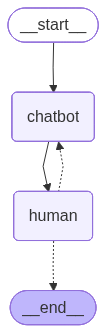

In [ ]:
from typing import Literal


def maybe_exit_human_node(state: OrderState) -> Literal["chatbot", "__end__"]:
    """Route to the chatbot, unless it looks like the user is exiting."""
    if state.get("finished", False):
        return END
    else:
        return "chatbot"


graph_builder.add_conditional_edges("human", maybe_exit_human_node)

chat_with_human_graph = graph_builder.compile()

Image(chat_with_human_graph.get_graph().draw_mermaid_png())

In [ ]:
# The default recursion limit for traversing nodes is 25 - setting it higher means
# you can try a more complex order with multiple steps and round-trips (and you
# can chat for longer!)
config = {"recursion_limit": 100}

# Remember that this will loop forever, unless you input `q`, `quit` or one of the
# other exit terms defined in `human_node`.
# Uncomment this line to execute the graph:
state = chat_with_human_graph.invoke({"messages": []}, config)

# Things to try:
#  - Just chat! There's no ordering or menu yet.
#  - 'q' to exit.

pprint(state)

Model: Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?
User: What kind of lattes can you make?
Model: We offer a variety of delicious lattes! You can choose from:

*   **Classic Vanilla Latte:** A smooth blend of espresso, steamed milk, and sweet vanilla syrup.
*   **Caramel Latte:** Rich espresso, creamy milk, and decadent caramel sauce.
*   **Mocha Latte:** A chocolate lover's dream with espresso, steamed milk, and rich chocolate syrup.
*   **Matcha Latte:** Earthy matcha green tea powder whisked with steamed milk for a vibrant and calming drink.
*   **Seasonal Latte:** Ask about our current seasonal special!

Would you like to hear more about any of these, or perhaps place an order?
User: Tell  me more about Caramel Latte
Model: Our Caramel Latte is a classic for a reason! It's made with our signature espresso roast, perfectly steamed milk, and a generous swirl of rich, buttery caramel sauce. It's a sweet and comforting choice. Would you like to add one 

## 1.3) Adding a live menu

BaristaBot currently has no awareness of the available items at the cafe, so it will hallucinate a menu. One option would be to hard-code a menu into the system prompt. This would work well, but to simulate a system where the menu is more dynamic and could respond to fluctuating stock levels, you will put the menu into a custom tool.

There are two types of tools that this system will use. Stateless tools that can be run automatically, and stateful tools that modify the order. The "get current menu" tool is stateless, in that it does not make any changes to the live order, so it can be called automatically.

In a LangGraph app, you can annotate Python functions as tools by applying the `@tools` annotation.

In [ ]:
from langchain_core.tools import tool


@tool
def get_menu() -> str:
    """Provide the latest up-to-date menu."""
    # Note that this is just hard-coded text, but you could connect this to a live stock
    # database, or you could use Gemini's multi-modal capabilities and take live photos of
    # your cafe's chalk menu or the products on the counter and assmble them into an input.

    return """
    MENU:
    Coffee Drinks:
    Espresso
    Americano
    Cold Brew

    Coffee Drinks with Milk:
    Latte
    Cappuccino
    Cortado
    Macchiato
    Mocha
    Flat White

    Tea Drinks:
    English Breakfast Tea
    Green Tea
    Earl Grey

    Tea Drinks with Milk:
    Chai Latte
    Matcha Latte
    London Fog

    Other Drinks:
    Steamer
    Hot Chocolate

    Modifiers:
    Milk options: Whole, 2%, Oat, Almond, 2% Lactose Free; Default option: whole
    Espresso shots: Single, Double, Triple, Quadruple; default: Double
    Caffeine: Decaf, Regular; default: Regular
    Hot-Iced: Hot, Iced; Default: Hot
    Sweeteners (option to add one or more): vanilla sweetener, hazelnut sweetener, caramel sauce, chocolate sauce, sugar free vanilla sweetener
    Special requests: any reasonable modification that does not involve items not on the menu, for example: 'extra hot', 'one pump', 'half caff', 'extra foam', etc.

    "dirty" means add a shot of espresso to a drink that doesn't usually have it, like "Dirty Chai Latte".
    "Regular milk" is the same as 'whole milk'.
    "Sweetened" means add some regular sugar, not a sweetener.

    Soy milk has run out of stock today, so soy is not available.
  """

Now add the new tool to the graph. The `get_menu` tool is wrapped in a `ToolNode` that handles calling the tool and passing the response as a message through the graph. The tools are also bound to the `llm` object so that the underlying model knows they exist. As you now have a different `llm` object to invoke, you need to update the `chatbot` node so that it is aware of the tools.

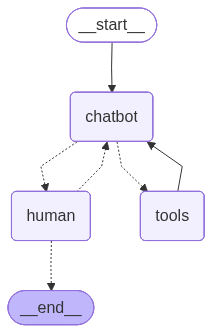

In [ ]:
from langgraph.prebuilt import ToolNode


# Define the tools and create a "tools" node.
tools = [get_menu]
tool_node = ToolNode(tools)

# Attach the tools to the model so that it knows what it can call.
llm_with_tools = llm.bind_tools(tools)


def maybe_route_to_tools(state: OrderState) -> Literal["tools", "human"]:
    """Route between human or tool nodes, depending if a tool call is made."""
    if not (msgs := state.get("messages", [])):
        raise ValueError(f"No messages found when parsing state: {state}")

    # Only route based on the last message.
    msg = msgs[-1]

    # When the chatbot returns tool_calls, route to the "tools" node.
    if hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:
        return "tools"
    else:
        return "human"


def chatbot_with_tools(state: OrderState) -> OrderState:
    """The chatbot with tools. A simple wrapper around the model's own chat interface."""
    defaults = {"order": [], "finished": False}

    if state["messages"]:
        new_output = llm_with_tools.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        new_output = AIMessage(content=WELCOME_MSG)

    # Set up some defaults if not already set, then pass through the provided state,
    # overriding only the "messages" field.
    return defaults | state | {"messages": [new_output]}


graph_builder = StateGraph(OrderState)

# Add the nodes, including the new tool_node.
graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tool_node)

# Chatbot may go to tools, or human.
graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
# Human may go back to chatbot, or exit.
graph_builder.add_conditional_edges("human", maybe_exit_human_node)

# Tools always route back to chat afterwards.
graph_builder.add_edge("tools", "chatbot")

graph_builder.add_edge(START, "chatbot")
graph_with_menu = graph_builder.compile()

Image(graph_with_menu.get_graph().draw_mermaid_png())

In [ ]:
# Remember that you have not implemented ordering yet, so this will loop forever,
# unless you input `q`, `quit` or one of the other exit terms defined in the
# `human_node`.

state = graph_with_menu.invoke({"messages": []}, config)

# Things to try:
# - I'd love an espresso drink, what have you got?
# - What teas do you have?
# - Can you do a long black? (this is on the menu as an "Americano" - see if it can
#   figure it out)
# - 'q' to exit.

# pprint(state)

Model: Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?
User: I'd love an espresso drink, what have you got?
Model: We have a variety of espresso drinks! You can get a straight Espresso, Americano, Latte, Cappuccino, Cortado, Macchiato, Mocha, or Flat White. We also have specialty espresso drinks like a Dirty Chai Latte. Do any of those sound good?
User: What teas do you have?
Model: We have English Breakfast Tea, Green Tea, and Earl Grey. For tea-based drinks with milk, we offer Chai Latte, Matcha Latte, and London Fog.
User: Can you do a long black?
Model: I'm sorry, but "long black" is not an item on our menu. I can offer you an Americano, which is similar. Would you like to hear more about that?
User: quit


## 1.4) Handling Orders

To build up an order during the chat conversation, you will need to update the state to track the order, and provide simple tools that update this state. These need to be explicit as the model should not directly have access to the apps internal state, or it risks being manipulated arbitrarily.

The ordering tools will be added as stubs in a separate node so that you can edit the state directly. Using the `@tool` annotation is still a handy way to define their schema, so the ordering tools below are implemented as empty Python functions.

In [ ]:
from collections.abc import Iterable
from random import randint

from langchain_core.messages.tool import ToolMessage

# These functions have no body; LangGraph does not allow @tools to update
# the conversation state, so you will implement a separate node to handle
# state updates. Using @tools is still very convenient for defining the tool
# schema, so empty functions have been defined that will be bound to the LLM
# but their implementation is deferred to the order_node.


@tool
def add_to_order(drink: str, modifiers: Iterable[str]) -> str:
    """Adds the specified drink to the customer's order, including any modifiers.

    Returns:
      The updated order in progress.
    """


@tool
def confirm_order() -> str:
    """Asks the customer if the order is correct.

    Returns:
      The user's free-text response.
    """


@tool
def get_order() -> str:
    """Returns the users order so far. One item per line."""


@tool
def clear_order():
    """Removes all items from the user's order."""


@tool
def place_order() -> int:
    """Sends the order to the barista for fulfillment.

    Returns:
      The estimated number of minutes until the order is ready.
    """


def order_node(state: OrderState) -> OrderState:
    """The ordering node. This is where the order state is manipulated."""
    tool_msg = state.get("messages", [])[-1]
    order = state.get("order", [])
    outbound_msgs = []
    order_placed = False

    for tool_call in tool_msg.tool_calls:

        if tool_call["name"] == "add_to_order":

            # Each order item is just a string. This is where it assembled as "drink (modifiers, ...)".
            modifiers = tool_call["args"]["modifiers"]
            modifier_str = ", ".join(modifiers) if modifiers else "no modifiers"

            order.append(f'{tool_call["args"]["drink"]} ({modifier_str})')
            response = "\n".join(order)

        elif tool_call["name"] == "confirm_order":

            # We could entrust the LLM to do order confirmation, but it is a good practice to
            # show the user the exact data that comprises their order so that what they confirm
            # precisely matches the order that goes to the kitchen - avoiding hallucination
            # or reality skew.

            # In a real scenario, this is where you would connect your POS screen to show the
            # order to the user.

            print("Your order:")
            if not order:
                print("  (no items)")

            for drink in order:
                print(f"  {drink}")

            response = input("Is this correct? ")

        elif tool_call["name"] == "get_order":

            response = "\n".join(order) if order else "(no order)"

        elif tool_call["name"] == "clear_order":

            order.clear()
            response = None

        elif tool_call["name"] == "place_order":

            order_text = "\n".join(order)
            print("Sending order to kitchen!")
            print(order_text)

            # TODO(you!): Implement cafe.
            order_placed = True
            response = randint(1, 5)  # ETA in minutes

        else:
            raise NotImplementedError(f'Unknown tool call: {tool_call["name"]}')

        # Record the tool results as tool messages.
        outbound_msgs.append(
            ToolMessage(
                content=response,
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )

    return {"messages": outbound_msgs, "order": order, "finished": order_placed}


def maybe_route_to_tools(state: OrderState) -> str:
    """Route between chat and tool nodes if a tool call is made."""
    if not (msgs := state.get("messages", [])):
        raise ValueError(f"No messages found when parsing state: {state}")

    msg = msgs[-1]

    if state.get("finished", False):
        # When an order is placed, exit the app. The system instruction indicates
        # that the chatbot should say thanks and goodbye at this point, so we can exit
        # cleanly.
        return END

    elif hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:
        # Route to `tools` node for any automated tool calls first.
        if any(
            tool["name"] in tool_node.tools_by_name.keys() for tool in msg.tool_calls
        ):
            return "tools"
        else:
            return "ordering"

    else:
        return "human"

Now define the graph. The LLM needs to know about the tools too, so that it can invoke them. Here you set up 2 sets of tools corresponding to the nodes under which they operate: automated and ordering.

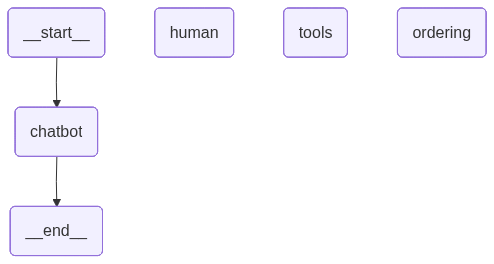

In [ ]:
# Auto-tools will be invoked automatically by the ToolNode
auto_tools = [get_menu]
tool_node = ToolNode(auto_tools)

# Order-tools will be handled by the order node.
order_tools = [add_to_order, confirm_order, get_order, clear_order, place_order]

# The LLM needs to know about all of the tools, so specify everything here.
llm_with_tools = llm.bind_tools(auto_tools + order_tools)


graph_builder = StateGraph(OrderState)

# Nodes
graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("ordering", order_node)

# Chatbot -> {ordering, tools, human, END}
graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
# Human -> {chatbot, END}
graph_builder.add_conditional_edges("human", maybe_exit_human_node)

# Tools (both kinds) always route back to chat afterwards.
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("ordering", "chatbot")

graph_builder.add_edge(START, "chatbot")
graph_with_order_tools = graph_builder.compile()

Image(graph_with_order_tools.get_graph().draw_mermaid_png())

In [ ]:
state = graph_with_order_tools.invoke({"messages": []}, config)

# Things to try:
# - Order a drink!
# - Make a change to your order.
# - "Which teas are from England?"
# - Note that the graph should naturally exit after placing an order.

# pprint(state)

Model: Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?
User: Which teas are from england
Model: The English Breakfast Tea and Earl Grey are both from England. The London Fog is also a popular tea from England.
User: I want to order a americano
Model: OK. Anything else?
User: nope
Your order:
  Americano (no modifiers)
Is this correct? no add goat milk on top of it
Model: I have an Americano with no goat milk on top. Does that look right?
User: no, add goat milk on top
Model: I am sorry, we do not have goat milk. Would you like to substitute that for another milk?
User: sure
Model: I have an Americano with whole milk. Does that look right?
User: yes
Sending order to kitchen!
Americano (no modifiers)
Americano (whole milk)


In [ ]:
pprint(state)

{'finished': True,
 'messages': [AIMessage(content='Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?', additional_kwargs={}, response_metadata={}, id='74817b48-dd75-44ee-bc38-cfbfbbe7a825', tool_calls=[], invalid_tool_calls=[]),
              HumanMessage(content='Which teas are from england', additional_kwargs={}, response_metadata={}, id='449127c0-b0cd-4460-bfb8-2044d92975b2'),
              AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_menu', 'arguments': '{}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d8d98-c0ee-7a71-ab97-bb802d39e581-0', tool_calls=[{'name': 'get_menu', 'args': {}, 'id': 'e6b4d2ca-63cc-4e2d-ba9c-ae48626893ce', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 608, 'output_tokens': 10, 'total_tokens': 618, 'input_token_details': {'cache_read': 0}}),
              ToolMess

# 2. Function Calling With Gemini

We'll use Gemini API's automatic function calling to build a chat interface over a local database. This example is a toy and is missing a number of safety and security constraints you would use in a real-world example, but shows how to add AI chat capabilities to existing applications with ease.

## 2.1) Creating a Local Database

In [ ]:
%load_ext sql
%sql sqlite:///sample.db

- Creating table and adding synthetic data

In [ ]:
%%sql
-- Create the 'products' table
CREATE TABLE IF NOT EXISTS products (
  	product_id INTEGER PRIMARY KEY AUTOINCREMENT,
  	product_name VARCHAR(255) NOT NULL,
  	price DECIMAL(10, 2) NOT NULL
  );

-- Create the 'staff' table
CREATE TABLE IF NOT EXISTS staff (
  	staff_id INTEGER PRIMARY KEY AUTOINCREMENT,
  	first_name VARCHAR(255) NOT NULL,
  	last_name VARCHAR(255) NOT NULL
  );

-- Create the 'orders' table
CREATE TABLE IF NOT EXISTS orders (
  	order_id INTEGER PRIMARY KEY AUTOINCREMENT,
  	customer_name VARCHAR(255) NOT NULL,
  	staff_id INTEGER NOT NULL,
  	product_id INTEGER NOT NULL,
  	FOREIGN KEY (staff_id) REFERENCES staff (staff_id),
  	FOREIGN KEY (product_id) REFERENCES products (product_id)
  );

-- Insert data into the 'products' table
INSERT INTO products (product_name, price) VALUES
  	('Laptop', 799.99),
  	('Keyboard', 129.99),
  	('Mouse', 29.99);

-- Insert data into the 'staff' table
INSERT INTO staff (first_name, last_name) VALUES
  	('Alice', 'Smith'),
  	('Bob', 'Johnson'),
  	('Charlie', 'Williams');

-- Insert data into the 'orders' table
INSERT INTO orders (customer_name, staff_id, product_id) VALUES
  	('David Lee', 1, 1),
  	('Emily Chen', 2, 2),
  	('Frank Brown', 1, 3);

 * sqlite:///sample.db
Done.
Done.
Done.
3 rows affected.
3 rows affected.
3 rows affected.


[]

In [30]:
import sqlite3

db_file = "sample.db"
db_conn = sqlite3.connect(db_file)

The first function will list all tables available in the database. Define it, and test it out to ensure it works.

In [31]:
def list_tables() -> list[str]:
    """Retrieve the names of all tables in the database."""
    # Include print logging statements so you can see when functions are being called.
    print(' - DB CALL: list_tables()')

    cursor = db_conn.cursor()

    # Fetch the table names.
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

    tables = cursor.fetchall()
    return [t[0] for t in tables]


list_tables()

 - DB CALL: list_tables()


['products', 'sqlite_sequence', 'staff', 'orders']

Once the available tables is known, the next step a database user will need is to understand what columns are available in a given table. Define that too, and test that it works as expected.

In [32]:
def describe_table(table_name: str) -> list[tuple[str, str]]:
    """Look up the table schema.

    Returns:
      List of columns, where each entry is a tuple of (column, type).
    """
    print(f' - DB CALL: describe_table({table_name})')

    cursor = db_conn.cursor()

    cursor.execute(f"PRAGMA table_info({table_name});")

    schema = cursor.fetchall()
    # [column index, column name, column type, ...]
    return [(col[1], col[2]) for col in schema]


describe_table("products")

 - DB CALL: describe_table(products)


[('product_id', 'INTEGER'),
 ('product_name', 'VARCHAR(255)'),
 ('price', 'DECIMAL(10, 2)')]

Now that the system knows what tables and columns are present, it has enough information to be able to generate and run a `SELECT` query. Now provide that functionality, and test that it works.

In [33]:
def execute_query(sql: str) -> list[list[str]]:
    """Execute an SQL statement, returning the results."""
    print(f' - DB CALL: execute_query({sql})')

    cursor = db_conn.cursor()

    cursor.execute(sql)
    return cursor.fetchall()


execute_query("select * from products")

 - DB CALL: execute_query(select * from products)


[(1, 'Laptop', 799.99), (2, 'Keyboard', 129.99), (3, 'Mouse', 29.99)]

## 2.2) Implementing Function Calls

Now you can put it all together in a call to the Gemini API.

Function calling works by adding specific messages to a chat session. When function schemas are defined and made available to the model and a conversation is started, instead of returning a text response, the model may return a `function_call` instead. When this happens, the client must respond with a `function_response`, indicating the result of the call, and the conversation can continue on as normal.

This function calling interaction normally happens manually, allowing you, the client, to validate and initiate the call. However the Python SDK also supports automatic function calling, where the supplied functions will be automatically invoked. This is a powerful feature and should be used with care, such as when the functions have no side-effects).

Here's the state diagram representing the conversation flow with function calling. With automatic function calling, the bottom row is executed automatically by the Python SDK. With manual function calling, you write the code to run each step individually.

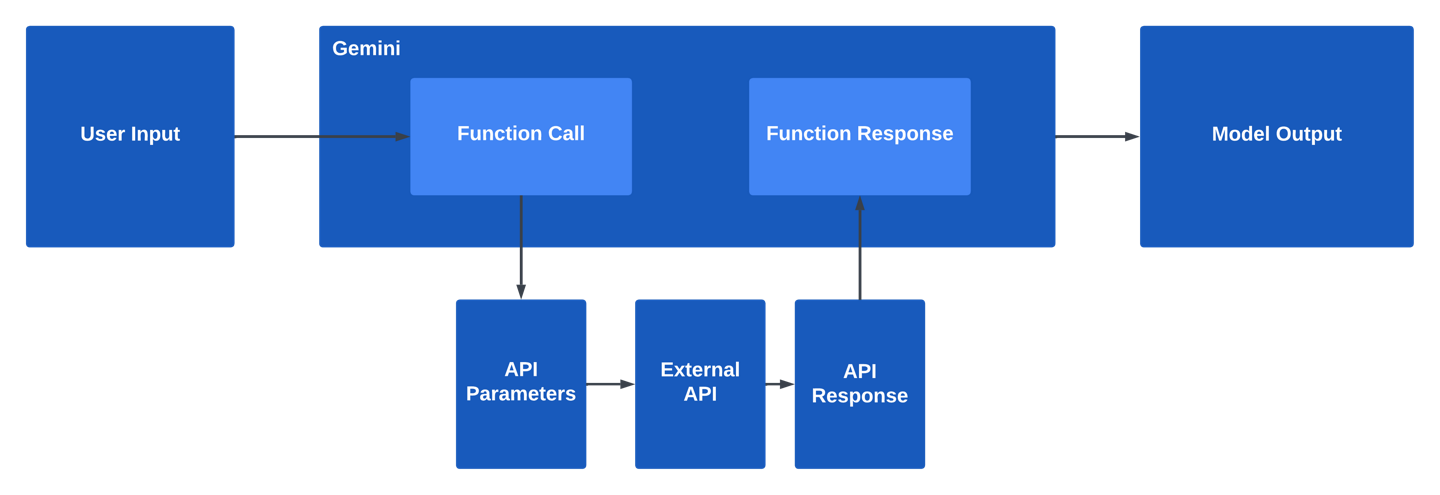

In [37]:
# These are the Python functions defined above.
db_tools = [list_tables, describe_table, execute_query]

instruction = """You are a helpful chatbot that can interact with an SQL database
for a computer store. You will take the users questions and turn them into SQL
queries using the tools available. Once you have the information you need, you will
answer the user's question using the data returned.

Use list_tables to see what tables are present, describe_table to understand the
schema, and execute_query to issue an SQL SELECT query."""

client = genai.Client(api_key=api_key)

# Start a chat with automatic function calling enabled.
chat = client.chats.create(
    model="gemini-2.5-flash-lite",
    config=types.GenerateContentConfig(
        system_instruction=instruction,
        tools=db_tools,
    ),
)

Now you can engage in a chat conversation where you can ask about the contents of the database.

In [39]:
resp = chat.send_message("What is the cheapest product?")
print(f"\n{resp.text}")

 - DB CALL: list_tables()
 - DB CALL: describe_table(products)
 - DB CALL: execute_query(SELECT product_name, price FROM products ORDER BY price ASC LIMIT 1)

The cheapest product is the Mouse, which costs $29.99.


## 2.3) Inspecting the Conversation

To see the calls that the model makes, and what the client returns in response, you can inspect the chat history. This helper function will print out each turn along with the relevant fields passed or returned.

In [41]:
import textwrap


def print_chat_turns(chat):
    """Prints out each turn in the chat history, including function calls and responses."""
    for event in chat.get_history():
        print(f"{event.role.capitalize()}:")

        for part in event.parts:
            if txt := part.text:
                print(f'  "{txt}"')
            elif fn := part.function_call:
                args = ", ".join(f"{key}={val}" for key, val in fn.args.items())
                print(f"  Function call: {fn.name}({args})")
            elif resp := part.function_response:
                print("  Function response:")
                # Safely get 'result' or fallback to the full response object
                if isinstance(resp.response, dict) and 'result' in resp.response:
                    content_to_print = str(resp.response['result'])
                else:
                    # If 'result' key is not present or if resp.response is not a dict
                    content_to_print = str(resp.response)
                print(textwrap.indent(content_to_print, "    "))

        print()


print_chat_turns(chat)

User:
  "What is the cheapest product?"

Model:
  Function call: execute_query(sql=SELECT ProductName, Price FROM Products ORDER BY Price ASC LIMIT 1)

User:
  Function response:
    {'error': "Failed to invoke function execute_query with converted arguments {'sql': 'SELECT ProductName, Price FROM Products ORDER BY Price ASC LIMIT 1'} from model returned function call argument {'sql': 'SELECT ProductName, Price FROM Products ORDER BY Price ASC LIMIT 1'} because of error no such column: ProductName"}

Model:
  "The product with the lowest price is not available in the database."

User:
  "What is the cheapest product?"

Model:
  Function call: list_tables()

User:
  Function response:
    ['products', 'sqlite_sequence', 'staff', 'orders']

Model:
  Function call: describe_table(table_name=products)

User:
  Function response:
    [('product_id', 'INTEGER'), ('product_name', 'VARCHAR(255)'), ('price', 'DECIMAL(10, 2)')]

Model:
  Function call: execute_query(sql=SELECT product_name, pric

## 2.4) Compositional Function Calling

Models can compose user-provided function calls together while generating code.

This means that the model is able to take the available tools, generate code that uses it, and execute it all.

The feature requires the Live API, so this step uses different setup code than most of the examples you have seen so far. As the Multimodal Live API is a bi-directional streaming service, everything is set up in advance and then executed. This is a little more complex but the result is quite powerful.

First define a function that will handle streaming model output. It will stream text output, handle tool-calling and show the generated code that the model writes and executes to fulfill the task.

In [42]:
from pprint import pformat
from IPython.display import display, Image, Markdown


async def handle_response(stream, tool_impl=None):
  """Stream output and handle any tool calls during the session."""
  all_responses = []

  async for msg in stream.receive():
    all_responses.append(msg)

    if text := msg.text:
      # Output any text chunks that are streamed back.
      if len(all_responses) < 2 or not all_responses[-2].text:
        # Display a header if this is the first text chunk.
        display(Markdown('### Text'))

      print(text, end='')

    elif tool_call := msg.tool_call:
      # Handle tool-call requests.
      for fc in tool_call.function_calls:
        display(Markdown('### Tool call'))

        # Execute the tool and collect the result to return to the model.
        if callable(tool_impl):
          try:
            result = tool_impl(**fc.args)
          except Exception as e:
            result = str(e)
        else:
          result = 'ok'

        tool_response = types.LiveClientToolResponse(
            function_responses=[types.FunctionResponse(
                name=fc.name,
                id=fc.id,
                response={'result': result},
            )]
        )
        await stream.send(input=tool_response)

    elif msg.server_content and msg.server_content.model_turn:
      # Print any messages showing code the model generated and ran.

      for part in msg.server_content.model_turn.parts:
          if code := part.executable_code:
            display(Markdown(
                f'### Code\n```\n{code.code}\n```'))

          elif result := part.code_execution_result:
            display(Markdown(f'### Result: {result.outcome}\n'
                             f'```\n{pformat(result.output)}\n```'))

          elif img := part.inline_data:
            display(Image(img.data))

  print()
  return all_responses

In [ ]:
model = 'gemini-3.1-flash-live-preview'
live_client = genai.Client(api_key=api_key, http_options={'api_version': 'v1alpha'})

# Wrap the existing execute_query tool you used in the earlier example.
execute_query_tool_def = types.FunctionDeclaration.from_callable(
    client=live_client, callable=execute_query)

# Provide the model with enough information to use the tool, such as describing
# the database so it understands which SQL syntax to use.
sys_int = """You are a database interface. Use the `execute_query` function
to answer the users questions by looking up information in the database,
running any necessary queries and responding to the user.

You need to look up table schema using sqlite3 syntax SQL, then once an
answer is found be sure to tell the user. If the user is requesting an
action, you must also execute the actions.
"""

config = types.LiveConnectConfig(
    response_modalities=["TEXT"],
    system_instruction=types.Content(parts=[types.Part.from_text(text=sys_int)]),
    tools=[
        types.Tool(code_execution=types.ToolCodeExecution()),
        types.Tool(function_declarations=[execute_query_tool_def]),
    ]
)

async with live_client.aio.live.connect(model=model, config=config) as session:

  message = "Please generate and insert 5 new rows in the orders table."
  print(f"> {message}\n")

  await session.send(input=message, end_of_turn=True)
  await handle_response(session, tool_impl=execute_query)


In [ ]:
async with live_client.aio.live.connect(model=model, config=config) as session:

  message = "Can you figure out the number of orders that were made by each of the staff?"

  print(f"> {message}\n")
  await session.send(input=message, end_of_turn=True)
  await handle_response(session, tool_impl=execute_query)

  message = "Generate and run some code to plot this as a python seaborn chart"

  print(f"> {message}\n")
  await session.send(input=message, end_of_turn=True)
  await handle_response(session, tool_impl=execute_query)

# Resources
1. <a href="https://www.kaggle.com/whitepaper-agents">Agents</a>
2. <a href="https://www.kaggle.com/whitepaper-agent-companion">Agents Companion</a>
3. <a href="https://www.kaggle.com/code/markishere/day-3-building-an-agent-with-langgraph/#IMPORTANT!">Agents With LangGraph</a>
4. <A href="https://www.kaggle.com/code/markishere/day-3-function-calling-with-the-gemini-api#Day-3---Function-calling-with-the-Gemini-API">Function Calls with Gemini</a>
5. <a href="https://docs.langchain.com/oss/python/langgraph/overview">LangGraph Docs</a>
6. <a href="https://github.com/google-gemini/cookbook/blob/main/quickstarts/Function_calling.ipynb">Function Calling Cookbook</a>